# 🔬 RetinaScan AI — Kaggle Edition
### Non-Invasive Blood Glucose Estimation from Retinal Fundus Images
**Improvements over v1:**
- ✅ Dice + Focal loss for U-Net (fixes class imbalance in segmentation)
- ✅ 40 U-Net epochs + 30 CNN epochs with Early Stopping
- ✅ Masks pre-cached to disk (10× faster CNN training)
- ✅ Proper Train / Val / Test split (70/15/15)
- ✅ Random Forest added alongside Lasso & CART
- ✅ Real CNN-predicted DR grade flows into glucose regression features
- ✅ Confidence thresholding on CNN output
- ✅ Kaggle paths — no Google Drive needed

**Dataset expected on Kaggle (add as dataset):**
- `Original_Images/` — retinal fundus JPGs/PNGs
- `Microaneurysms_Masks/`, `Hemohedge_Masks/`, `HardExudate_Masks/`, `SoftExudate_Masks/`, `Neovascularization_Masks/`, `IRMA_Masks/`
- `DR_Seg_Grading_Label.csv`
- `hba1c_glucose.xlsx`


In [1]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [2]:
print(os.listdir('/kaggle/input/datasets'))
print(os.listdir('/kaggle/input/datasets/shrvx08'))
print(os.listdir('/kaggle/input/datasets/shrvx08/fgadr-seg-set'))
print(os.listdir('/kaggle/input/datasets/shrvx08/fgadr-seg-set/Seg-set'))

['shrvx08']
['retina-image', 'fgadr-seg-set', 'retinascan-models']
['Seg-set']
['IRMA_Masks', 'SoftExudate_Masks', 'hba1c_glucose.xlsx', 'HardExudate_Masks', 'Hemohedge_Masks', 'Microaneurysms_Masks', 'Original_Images', 'DR_Seg_Grading_Label.csv', 'Neovascularization_Masks']


In [3]:
print(os.listdir('/kaggle/input/datasets/shrvx08'))
print(os.listdir('/kaggle/input/datasets/shrvx08/retinascan-models'))

['retina-image', 'fgadr-seg-set', 'retinascan-models']
['cnn_drgrade_checkpoint.pth', 'unet_efficientb4_checkpoint.pth', 'unet_efficientb4_fgadr.pth', 'cnn_drgrade_resnet50.pth']


In [4]:
# %%capture- used to hide the outputs
# !pip install segmentation-models-pytorch albumentations openpyxl -q
# print("Packages ready.")
# print("done")

!pip install -q --upgrade segmentation-models-pytorch
!pip install -q albumentations openpyxl
print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:0000:01
Done.


In [5]:

import subprocess

# Uninstall conflicting versions first
subprocess.run(['pip', 'uninstall', '-y', 'torch', 'torchvision', 'torchaudio',
                'segmentation-models-pytorch'], capture_output=True)

# Install PyTorch with CUDA 12.1 (matches Kaggle P100 current environment)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q

# Reinstall smp after torch is fixed
!pip install segmentation-models-pytorch albumentations openpyxl -q

print("Done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 3.3 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 80.3 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 67.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 37.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 79.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 14.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 31.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━

In [6]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
print(f'CUDA version    : {torch.version.cuda}')
print(f'GPU             : {torch.cuda.get_device_name(0)}')

# Quick sanity check
x = torch.randn(1, 3, 64, 64).cuda()
print(f'Tensor on GPU   : {x.device} ✅')

PyTorch version : 2.5.1+cu121
CUDA available  : True
CUDA version    : 12.1
GPU             : Tesla P100-PCIE-16GB
Tensor on GPU   : cuda:0 ✅


In [7]:
import segmentation_models_pytorch as smp
print(smp.__version__)

0.5.0


In [8]:
import os, cv2, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path
from tqdm import tqdm
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as T

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import Lasso, LassoCV, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, mean_absolute_error, mean_squared_error, r2_score
)

warnings.filterwarnings('ignore')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Kaggle Paths ──
# Adjust DATASET_NAME to match your Kaggle dataset slug
DATASET_NAME = 'fgadr-seg-set'          # change if different
BASE_DIR     = Path('/kaggle/input/datasets/shrvx08/fgadr-seg-set/Seg-set')
IMAGE_DIR    = BASE_DIR / 'Original_Images'
CSV_PATH     = BASE_DIR / 'DR_Seg_Grading_Label.csv'
GLUCOSE_XLSX = str(BASE_DIR / 'hba1c_glucose.xlsx')

OUTPUT_DIR   = Path('/kaggle/working/outputs')
MODEL_DIR    = Path('/kaggle/working/models')
CACHE_DIR    = Path('/kaggle/working/mask_cache')   # pre-computed masks
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ──
IMG_SIZE     = 512
SEG_BATCH    = 4          # U-Net batch (increase if GPU allows)
SEG_EPOCHS   = 28        # was 10 — more epochs needed
SEG_LR       = 2e-4
CNN_BATCH    = 16
CNN_EPOCHS   = 23       # was 18
CNN_LR       = 1e-4
PATIENCE     = 7          # early stopping patience
CONF_THRESH  = 0.45       # min CNN confidence before flagging uncertain

# ── Lesion folders ──
LESION_FOLDERS = {
    1: BASE_DIR / 'Microaneurysms_Masks',
    2: BASE_DIR / 'Hemohedge_Masks',
    3: BASE_DIR / 'HardExudate_Masks',
    4: BASE_DIR / 'SoftExudate_Masks',
    5: BASE_DIR / 'Neovascularization_Masks',
    6: BASE_DIR / 'IRMA_Masks',
}
LESION_NAMES = {
    1: 'Microaneurysms', 2: 'Hemorrhages', 3: 'HardExudates',
    4: 'SoftExudates',   5: 'Neovascularization', 6: 'IRMA',
}
LESION_COLORS = {
    0:[0,0,0], 1:[255,0,0], 2:[0,255,0], 3:[0,0,255],
    4:[255,255,0], 5:[255,0,255], 6:[0,255,255]
}

DR_TO_HBA1C = {
    0: {'range': (5.5,  6.5),  'label': 'No DR',            'risk': 'Low',          'color': '#22C55E'},
    1: {'range': (6.5,  7.5),  'label': 'Mild DR',          'risk': 'Low-Moderate', 'color': '#EAB308'},
    2: {'range': (7.5,  8.5),  'label': 'Moderate DR',      'risk': 'Moderate',     'color': '#F97316'},
    3: {'range': (8.5,  10.0), 'label': 'Severe DR',        'risk': 'High',         'color': '#EF4444'},
    4: {'range': (10.0, 12.0), 'label': 'Proliferative DR', 'risk': 'Very High',    'color': '#991B1B'},
}

# ── Verify dataset paths ──
print('\nVerifying dataset:')
for cls_id, folder in LESION_FOLDERS.items():
    exists = folder.exists()
    count  = len(list(folder.glob('*'))) if exists else 0
    print(f'  {"✅" if exists else "❌"} {folder.name}: {count} files')
print(f'  {"✅" if IMAGE_DIR.exists() else "❌"} Original_Images')
print(f'  {"✅" if CSV_PATH.exists()   else "❌"} DR_Seg_Grading_Label.csv')
print(f'  {"✅" if Path(GLUCOSE_XLSX).exists() else "❌"} hba1c_glucose.xlsx')
print('\nConfig ready! ✅')


Device: cuda
GPU: Tesla P100-PCIE-16GB

Verifying dataset:
  ✅ Microaneurysms_Masks: 1842 files
  ✅ Hemohedge_Masks: 1842 files
  ✅ HardExudate_Masks: 1842 files
  ✅ SoftExudate_Masks: 1842 files
  ✅ Neovascularization_Masks: 49 files
  ✅ IRMA_Masks: 159 files
  ✅ Original_Images
  ✅ DR_Seg_Grading_Label.csv
  ✅ hba1c_glucose.xlsx

Config ready! ✅


In [9]:
import shutil
from pathlib import Path

PRETRAINED_DIR = Path('/kaggle/input/datasets/shrvx08/retinascan-models')
MODEL_DIR      = Path('/kaggle/working/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    'unet_efficientb4_checkpoint.pth',
    'unet_efficientb4_fgadr.pth',
    'cnn_drgrade_checkpoint.pth',
    'cnn_drgrade_resnet50.pth',
]

for fname in files_to_copy:
    src = PRETRAINED_DIR / fname
    dst = MODEL_DIR / fname
    if src.exists() and not dst.exists():
        shutil.copy(str(src), str(dst))
        print(f'  Copied: {fname}')
    elif dst.exists():
        print(f'  Already exists: {fname}')
    else:
        print(f'  ❌ Not found: {fname}')

  Copied: unet_efficientb4_checkpoint.pth
  Copied: unet_efficientb4_fgadr.pth
  Copied: cnn_drgrade_checkpoint.pth
  Copied: cnn_drgrade_resnet50.pth


## Module 1 — Preprocessing

In [10]:
def ben_graham(image, sigma=10):
    """Removes uneven illumination."""
    return cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0,0), sigma), -4, 128)

def apply_clahe(image, clip_limit=3.0, tile_size=8):
    """CLAHE on LAB L-channel."""
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def remove_black_border(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(mask)
    if coords is None:
        return image
    x, y, w, h = cv2.boundingRect(coords)
    return image[y:y+h, x:x+w]

def preprocess_fundus(image, target_size=512):
    image = remove_black_border(image)
    image = ben_graham(image)
    image = apply_clahe(image)
    image = cv2.resize(image, (target_size, target_size))
    return np.clip(image, 0, 255).astype(np.uint8)

print('Preprocessing functions defined ✅')


Preprocessing functions defined ✅


## Load CSV — 70 / 15 / 15 Train / Val / Test Split

Total samples: 1842
DR Grade distribution:
dr_grade
0    101
1    212
2    595
3    647
4    287
Name: count, dtype: int64

Train: 1288 | Val: 277 | Test: 277


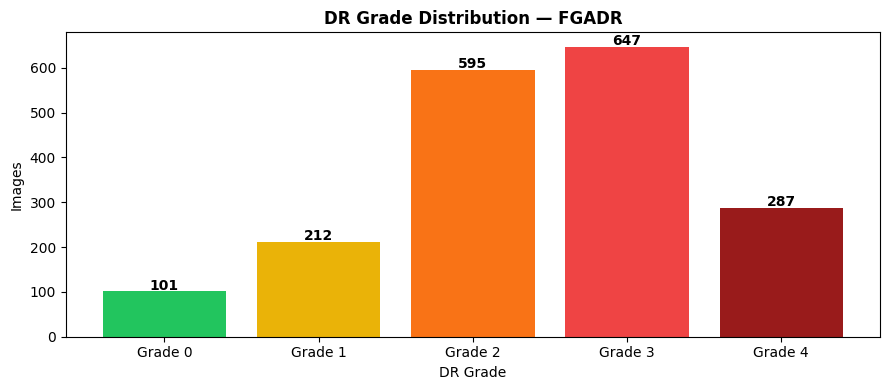

In [12]:
df = pd.read_csv(CSV_PATH, header=None, names=['image', 'dr_grade'])
print(f'Total samples: {len(df)}')
print('DR Grade distribution:')
print(df['dr_grade'].value_counts().sort_index())

# ── Proper 3-way split ──
df_train_val, df_test = train_test_split(df, test_size=0.15, random_state=42, stratify=df['dr_grade'])
df_train, df_val      = train_test_split(df_train_val, test_size=0.1765,  # 0.15/0.85 ≈ 0.1765 → ~15% of total
                                          random_state=42, stratify=df_train_val['dr_grade'])

print(f'\nTrain: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

fig, ax = plt.subplots(figsize=(9, 4))
counts = df['dr_grade'].value_counts().sort_index()
colors = ['#22C55E','#EAB308','#F97316','#EF4444','#991B1B']
bars   = ax.bar([f'Grade {i}' for i in counts.index], counts.values, color=colors)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4, str(val), ha='center', fontweight='bold')
ax.set_title('DR Grade Distribution — FGADR', fontweight='bold')
ax.set_xlabel('DR Grade'); ax.set_ylabel('Images')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'grade_distribution.png', dpi=150); plt.show()


## Module 2 — U-Net Segmentation

In [13]:
def get_seg_transforms(phase='train'):
    if phase == 'train':
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.3), A.RandomRotate90(p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2, p=0.4),
            A.GaussNoise(var_limit=(5.0, 30.0), p=0.3),
            A.ElasticTransform(p=0.25), A.GridDistortion(p=0.2),
            A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2(),
    ])


class FGADRSegDataset(Dataset):
    def __init__(self, df_split, transform=None):
        # Use full image list for segmentation (no grade needed)
        all_images = sorted(list(IMAGE_DIR.glob('*.jpg')) + list(IMAGE_DIR.glob('*.png')))
        # map by stem for fast lookup
        self.image_paths = all_images
        self.transform   = transform

    def __len__(self): return len(self.image_paths)

    def _combined_mask(self, img_name):
        combined = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        stem = Path(img_name).stem
        for cls_id, folder in LESION_FOLDERS.items():
            for ext in ['.png', '.jpg']:
                mp = folder / (stem + ext)
                if mp.exists():
                    m = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
                    m = cv2.resize(m, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
                    combined[m > 127] = cls_id
                    break
        return combined

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image    = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        image    = preprocess_fundus(image, target_size=IMG_SIZE)
        mask     = self._combined_mask(Path(img_path).name)
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']; mask = aug['mask']
        return image, mask.long()


all_images           = sorted(list(IMAGE_DIR.glob('*.jpg')) + list(IMAGE_DIR.glob('*.png')))
train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)

seg_train_ds     = FGADRSegDataset(None, get_seg_transforms('train'))
seg_val_ds       = FGADRSegDataset(None, get_seg_transforms('val'))

# override paths properly
seg_train_ds.image_paths = train_imgs
seg_val_ds.image_paths   = val_imgs

seg_train_loader = DataLoader(seg_train_ds, batch_size=SEG_BATCH, shuffle=True,  num_workers=0, pin_memory=False)
seg_val_loader   = DataLoader(seg_val_ds,   batch_size=SEG_BATCH, shuffle=False, num_workers=0, pin_memory=False)

print(f'Seg — Train: {len(train_imgs)} | Val: {len(val_imgs)}')


Seg — Train: 1473 | Val: 369


### Dice + Focal Loss (Key Fix #1)

In [14]:
class DiceLoss(nn.Module):
    """Multi-class Dice loss — directly optimises overlap, handles class imbalance better."""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets, num_classes=7):
        probs   = torch.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
        dims    = (0, 2, 3)
        inter   = (probs * targets_oh).sum(dim=dims)
        union   = (probs + targets_oh).sum(dim=dims)
        dice    = (2 * inter + self.smooth) / (union + self.smooth)
        # skip background class (index 0) in dice
        return 1 - dice[1:].mean()


class FocalLoss(nn.Module):
    """Focal loss — down-weights easy negatives, focuses on hard misclassified pixels."""
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt   = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


class CombinedSegLoss(nn.Module):
    """Focal + Dice combined — best of both worlds for medical segmentation."""
    def __init__(self, alpha=0.5, gamma=2.0):
        super().__init__()
        # Higher weight for rare lesion classes
        cls_weights = torch.tensor([0.1, 1.5, 1.5, 1.2, 1.8, 4.0, 4.0], device=DEVICE)
        self.focal  = FocalLoss(gamma=gamma, weight=cls_weights)
        self.dice   = DiceLoss()
        self.alpha  = alpha   # weight of focal vs dice

    def forward(self, logits, targets):
        return self.alpha * self.focal(logits, targets) + (1 - self.alpha) * self.dice(logits, targets)


def mean_iou(preds, targets, n=7):
    ious = []
    for c in range(1, n):
        p = (preds == c); t = (targets == c)
        inter = (p & t).sum().float()
        union = (p | t).sum().float()
        if union > 0:
            ious.append((inter / union).item())
    return float(np.mean(ious)) if ious else 0.0

print('Dice + Focal loss defined ✅')


Dice + Focal loss defined ✅


### Build U-Net (EfficientNet-B4)

In [15]:
def build_unet():
    return smp.Unet(
        encoder_name='efficientnet-b4',
        encoder_weights='imagenet',
        in_channels=3,
        classes=7,
        activation=None,
    ).to(DEVICE)

seg_model    = build_unet()
total_params = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)
print(f'U-Net ready! Params: {total_params:,}')
test_out = seg_model(torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print(f'Output shape: {test_out.shape} ✅')


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

U-Net ready! Params: 20,226,559
Output shape: torch.Size([1, 7, 512, 512]) ✅


In [16]:
import os

print("Files in MODEL_DIR:")
for f in sorted(MODEL_DIR.iterdir()):
    size = f.stat().st_size / 1e6
    print(f"  {f.name:<45} {size:.1f} MB")

print("\nFiles in Kaggle input (pretrained models):")
PRETRAINED_DIR = Path('/kaggle/input/datasets/shrvx08/retinascan-models')
if PRETRAINED_DIR.exists():
    for f in sorted(PRETRAINED_DIR.iterdir()):
        size = f.stat().st_size / 1e6
        print(f"  {f.name:<45} {size:.1f} MB")
else:
    print("  ❌ /kaggle/input/datasets/shrvx08/retinascan-models not found")

Files in MODEL_DIR:
  cnn_drgrade_checkpoint.pth                    296.8 MB
  cnn_drgrade_resnet50.pth                      99.1 MB
  unet_efficientb4_checkpoint.pth               237.5 MB
  unet_efficientb4_fgadr.pth                    81.7 MB

Files in Kaggle input (pretrained models):
  cnn_drgrade_checkpoint.pth                    296.8 MB
  cnn_drgrade_resnet50.pth                      99.1 MB
  unet_efficientb4_checkpoint.pth               237.5 MB
  unet_efficientb4_fgadr.pth                    81.7 MB


In [17]:
UNET_PATH = MODEL_DIR / 'unet_efficientb4_fgadr.pth'
UNET_CKPT = MODEL_DIR / 'unet_efficientb4_checkpoint.pth'

print(f'UNET_PATH exists : {UNET_PATH.exists()}  → {UNET_PATH}')
print(f'UNET_CKPT exists : {UNET_CKPT.exists()}  → {UNET_CKPT}')
print(f'Condition (load only, no train): {UNET_PATH.exists() and not UNET_CKPT.exists()}')

# Peek inside the checkpoint
ckpt = torch.load(UNET_CKPT, map_location='cpu')
print(f'\nCheckpoint contents : {list(ckpt.keys())}')
print(f'Saved at epoch      : {ckpt["epoch"]}')
print(f'Best mIoU so far    : {ckpt["best_iou"]:.4f}')
print(f'No improve count    : {ckpt.get("no_improve", 0)}')

UNET_PATH exists : True  → /kaggle/working/models/unet_efficientb4_fgadr.pth
UNET_CKPT exists : True  → /kaggle/working/models/unet_efficientb4_checkpoint.pth
Condition (load only, no train): False

Checkpoint contents : ['epoch', 'model_state', 'optimizer_state', 'scheduler_state', 'best_iou', 'history']
Saved at epoch      : 9
Best mIoU so far    : 0.0816
No improve count    : 0


In [18]:
UNET_PATH = MODEL_DIR / 'unet_efficientb4_fgadr.pth'
UNET_CKPT = MODEL_DIR / 'unet_efficientb4_checkpoint.pth'   # ← was 'unet_checkpoint.pth'

def train_unet(model, train_loader, val_loader):
    optimizer  = optim.AdamW(model.parameters(), lr=SEG_LR, weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SEG_EPOCHS, eta_min=1e-6)
    criterion  = CombinedSegLoss(alpha=0.5, gamma=2.0)
    best_iou   = 0.0; no_improve = 0; start_epoch = 0
    history    = {'train': [], 'val': [], 'iou': []}

    if UNET_CKPT.exists():
        print('Resuming U-Net from checkpoint...')
        ckpt = torch.load(UNET_CKPT, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        best_iou    = ckpt['best_iou']
        start_epoch = ckpt['epoch'] + 1
        history     = ckpt['history']
        no_improve  = ckpt.get('no_improve', 0)
        print(f'Resumed from epoch {start_epoch} | Best mIoU: {best_iou:.4f}')
    else:
        print(f'Training U-Net from scratch for {SEG_EPOCHS} epochs...')

    for epoch in range(start_epoch, SEG_EPOCHS):
        model.train(); tloss = 0.0
        for imgs, masks in tqdm(train_loader, desc=f'U-Net {epoch+1}/{SEG_EPOCHS}', leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), masks)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            tloss += loss.item()

        model.eval(); vloss = 0.0; viou = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                preds  = model(imgs)
                vloss += criterion(preds, masks).item()
                viou  += mean_iou(preds.argmax(dim=1), masks)

        tloss /= len(train_loader); vloss /= len(val_loader); viou /= len(val_loader)
        history['train'].append(tloss); history['val'].append(vloss); history['iou'].append(viou)
        scheduler.step()
        print(f'Epoch {epoch+1:02d}/{SEG_EPOCHS} | Train Loss: {tloss:.4f} | Val Loss: {vloss:.4f} | mIoU: {viou:.4f}')

        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'scheduler_state': scheduler.state_dict(),
                    'best_iou': best_iou, 'history': history, 'no_improve': no_improve}, UNET_CKPT)

        if viou > best_iou:
            best_iou   = viou; no_improve = 0
            torch.save(model.state_dict(), UNET_PATH)
            print(f'  ✅ Best U-Net saved (mIoU: {best_iou:.4f})')
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)')
                break

    return history, best_iou


# Train or load
if UNET_PATH.exists() and not UNET_CKPT.exists():
    print('Loading pre-trained U-Net (no checkpoint — inference only)...')
    seg_model.load_state_dict(torch.load(UNET_PATH, map_location=DEVICE))
else:
    unet_history, unet_best_iou = train_unet(seg_model, seg_train_loader, seg_val_loader)
    print(f'\nU-Net training complete! Best mIoU: {unet_best_iou:.4f}')

seg_model.load_state_dict(torch.load(UNET_PATH, map_location=DEVICE))
seg_model.eval()
print('Best U-Net weights loaded ✅')

Resuming U-Net from checkpoint...
Resumed from epoch 10 | Best mIoU: 0.0816


Epoch 11/28 | Train Loss: 0.5198 | Val Loss: 0.5191 | mIoU: 0.0887
  ✅ Best U-Net saved (mIoU: 0.0887)


Epoch 12/28 | Train Loss: 0.5175 | Val Loss: 0.5168 | mIoU: 0.0862


Epoch 13/28 | Train Loss: 0.5152 | Val Loss: 0.5127 | mIoU: 0.0770


Epoch 14/28 | Train Loss: 0.5091 | Val Loss: 0.5093 | mIoU: 0.0732


...

Epoch 24/28 | Train Loss: 0.4740 | Val Loss: 0.4757 | mIoU: 0.1082
  ✅ Best U-Net saved (mIoU: 0.1082)


Epoch 25/28 | Train Loss: 0.4700 | Val Loss: 0.4741 | mIoU: 0.1116
  ✅ Best U-Net saved (mIoU: 0.1116)


Epoch 26/28 | Train Loss: 0.4690 | Val Loss: 0.4780 | mIoU: 0.1025


Epoch 27/28 | Train Loss: 0.4686 | Val Loss: 0.4784 | mIoU: 0.0994


Epoch 28/28 | Train Loss: 0.4669 | Val Loss: 0.4745 | mIoU: 0.0976

U-Net training complete! Best mIoU: 0.1116
Best U-Net weights loaded ✅


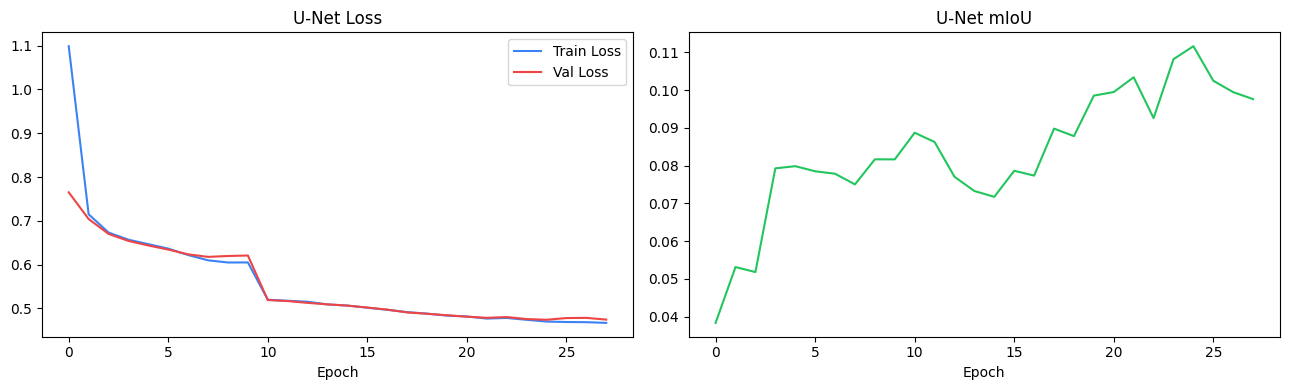

In [19]:
if 'unet_history' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(unet_history['train'], label='Train Loss', color='#3b82f6')
    axes[0].plot(unet_history['val'],   label='Val Loss',   color='#ef4444')
    axes[0].set_title('U-Net Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
    axes[1].plot(unet_history['iou'], color='#22c55e')
    axes[1].set_title('U-Net mIoU'); axes[1].set_xlabel('Epoch')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR/'unet_training.png', dpi=150); plt.show()


## Key Fix #2 — Pre-cache U-Net Masks to Disk

In [20]:
def cache_all_masks(image_paths, cache_dir, model, batch_size=4):
    """
    Run U-Net once over all images and save masks as .npy files.
    CNN training then loads from cache — no repeated U-Net inference.
    """
    model.eval()
    val_tf = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2()
    ])
    cached = 0
    print(f'Caching {len(image_paths)} masks...')
    for i in tqdm(range(0, len(image_paths), batch_size)):
        batch_paths = image_paths[i:i+batch_size]
        tensors = []
        for p in batch_paths:
            img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
            img = preprocess_fundus(img, target_size=IMG_SIZE)
            t   = val_tf(image=img, mask=np.zeros((IMG_SIZE,IMG_SIZE), dtype=np.uint8))['image']
            tensors.append(t)
        batch_tensor = torch.stack(tensors).to(DEVICE)
        with torch.no_grad():
            masks = model(batch_tensor).argmax(dim=1).cpu().numpy().astype(np.uint8)
        for p, mask in zip(batch_paths, masks):
            npy_path = cache_dir / (Path(p).stem + '.npy')
            np.save(str(npy_path), mask)
            cached += 1
    print(f'Cached {cached} masks to {cache_dir} ✅')


all_images = sorted(list(IMAGE_DIR.glob('*.jpg')) + list(IMAGE_DIR.glob('*.png')))

# Only cache if not already done
existing = list(CACHE_DIR.glob('*.npy'))
if len(existing) < len(all_images):
    cache_all_masks(all_images, CACHE_DIR, seg_model, batch_size=SEG_BATCH)
else:
    print(f'Masks already cached ({len(existing)} files) ✅')


Caching 1842 masks...


100%|██████████| 461/461 [04:40<00:00,  1.64it/s]

Cached 1842 masks to /kaggle/working/mask_cache ✅


## Module 3 — CNN Classification (ResNet-50, 4-channel)

In [21]:
class DRGradeDataset(Dataset):
    """
    CNN dataset using PRE-CACHED masks — fast, no repeated U-Net calls.
    Input: 4-channel tensor = RGB (224×224) + lesion mask (1 ch, normalised /6).
    """
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = str(row['image'])
        if not img_name.endswith(('.jpg', '.png')):
            img_name += '.jpg'
        img_path = IMAGE_DIR / img_name
        if not img_path.exists():
            img_path = IMAGE_DIR / (Path(img_name).stem + '.png')

        image     = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        image_512 = preprocess_fundus(image, target_size=IMG_SIZE)

        # Load cached mask (fast — no GPU needed)
        npy_path  = CACHE_DIR / (Path(img_name).stem + '.npy')
        mask_512  = np.load(str(npy_path)).astype(np.float32) if npy_path.exists() else np.zeros((IMG_SIZE, IMG_SIZE), np.float32)

        image_224 = cv2.resize(image_512, (224, 224))
        mask_224  = cv2.resize(mask_512,  (224, 224), interpolation=cv2.INTER_NEAREST)

        if self.transform:
            rgb_t = self.transform(image_224)
        else:
            rgb_t = T.ToTensor()(image_224)

        mask_t    = torch.tensor(mask_224 / 6.0).unsqueeze(0).float()
        image_4ch = torch.cat([rgb_t, mask_t], dim=0)   # 4 × 224 × 224
        return image_4ch, int(row['dr_grade'])


cnn_train_tf = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15, hue=0.05),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
cnn_val_tf = T.Compose([
    T.ToPILImage(), T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Filter to only images that exist
def filter_df(df):
    valid = []
    for _, row in df.iterrows():
        nm = str(row['image'])
        if not nm.endswith(('.jpg','.png')): nm += '.jpg'
        if (IMAGE_DIR/nm).exists() or (IMAGE_DIR/(Path(nm).stem+'.png')).exists():
            valid.append(row)
    return pd.DataFrame(valid).reset_index(drop=True)

df_train_f = filter_df(df_train)
df_val_f   = filter_df(df_val)
df_test_f  = filter_df(df_test)

train_ds   = DRGradeDataset(df_train_f, cnn_train_tf)
val_ds     = DRGradeDataset(df_val_f,   cnn_val_tf)
test_ds    = DRGradeDataset(df_test_f,  cnn_val_tf)

# ── Weighted sampler to fix class imbalance (Key Fix for Grade 0 & 1) ──
grade_counts   = df_train_f['dr_grade'].value_counts().sort_index()
class_weights  = 1.0 / grade_counts
sample_weights = df_train_f['dr_grade'].map(class_weights).values
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader   = DataLoader(train_ds, batch_size=CNN_BATCH, sampler=sampler,  num_workers=0, pin_memory=False)
val_loader     = DataLoader(val_ds,   batch_size=CNN_BATCH, shuffle=False,    num_workers=0, pin_memory=False)
test_loader    = DataLoader(test_ds,  batch_size=CNN_BATCH, shuffle=False,    num_workers=0, pin_memory=False)

print(f'CNN — Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print('Weighted sampler active for class balance ✅')


CNN — Train: 1288 | Val: 277 | Test: 277
Weighted sampler active for class balance ✅


### Build CNN (ResNet-50, 4-channel input, layer-wise LR)

In [22]:
class DRGradeCNN(nn.Module):
    """
    ResNet-50 fine-tuned for DR grade classification.
    conv1 modified: 3-channel → 4-channel (RGB + lesion mask).
    Custom head: FC(2048→512) → BN → ReLU → Dropout → FC(512→256) → FC(256→5)
    """
    def __init__(self, num_classes=5, dropout=0.45):
        super().__init__()
        backbone       = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        old_conv       = backbone.conv1
        backbone.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            backbone.conv1.weight[:, :3] = old_conv.weight
            backbone.conv1.weight[:,  3] = old_conv.weight.mean(dim=1)
        self.features   = nn.Sequential(*list(backbone.children())[:-1])
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(512,  256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(dropout*0.6),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

    def get_param_groups(self, base_lr):
        early, middle, late = [], [], []
        for name, param in self.features.named_parameters():
            top = int(name.split('.')[0])
            if   top <= 4: early.append(param)
            elif top <= 6: middle.append(param)
            else:          late.append(param)
        return [
            {'params': early,                             'lr': base_lr * 0.05},
            {'params': middle,                            'lr': base_lr * 0.1},
            {'params': late,                              'lr': base_lr * 0.5},
            {'params': list(self.classifier.parameters()), 'lr': base_lr},
        ]


cnn_model    = DRGradeCNN(num_classes=5, dropout=0.45).to(DEVICE)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'CNN (ResNet-50) ready!  Params: {total_params:,}')
dummy = torch.randn(2, 4, 224, 224).to(DEVICE)
print(f'Test output shape: {cnn_model(dummy).shape} ✅')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s] 


CNN (ResNet-50) ready!  Params: 24,694,405
Test output shape: torch.Size([2, 5]) ✅


In [23]:
CNN_PATH = MODEL_DIR / 'cnn_drgrade_resnet50.pth'
CNN_CKPT = MODEL_DIR / 'cnn_drgrade_checkpoint.pth'
   

def train_cnn(model, train_loader, val_loader):
    # Label smoothing helps with overconfidence on small classes
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.get_param_groups(CNN_LR), weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
    best_acc  = 0.0; no_improve = 0; start_epoch = 0
    history   = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    if CNN_CKPT.exists():
        print('Resuming CNN from checkpoint...')
        ckpt = torch.load(CNN_CKPT, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        best_acc    = ckpt['best_acc']
        start_epoch = ckpt['epoch'] + 1
        history     = ckpt['history']
        no_improve  = ckpt.get('no_improve', 0)
        print(f'Resumed epoch {start_epoch} | Best Acc: {best_acc:.4f}')
    else:
        print(f'Training CNN from scratch for {CNN_EPOCHS} epochs...')

    for epoch in range(start_epoch, CNN_EPOCHS):
        model.train(); tloss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f'CNN {epoch+1}/{CNN_EPOCHS}', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            tloss += loss.item()

        model.eval(); vloss = 0.0; vcorrect = 0; vtotal = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits  = model(imgs)
                vloss  += criterion(logits, labels).item()
                preds   = logits.argmax(1)
                vcorrect += (preds == labels).sum().item()
                vtotal   += labels.size(0)

        tloss   /= len(train_loader); vloss /= len(val_loader)
        val_acc  = vcorrect / vtotal
        history['train_loss'].append(tloss)
        history['val_loss'].append(vloss)
        history['val_acc'].append(val_acc)
        scheduler.step()
        print(f'Epoch {epoch+1:02d}/{CNN_EPOCHS} | Train Loss: {tloss:.4f} | Val Loss: {vloss:.4f} | Val Acc: {val_acc:.4f}')

        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'scheduler_state': scheduler.state_dict(),
                    'best_acc': best_acc, 'history': history, 'no_improve': no_improve}, CNN_CKPT)

        if val_acc > best_acc:
            best_acc   = val_acc; no_improve = 0
            torch.save(model.state_dict(), CNN_PATH)
            print(f'  ✅ Best CNN saved (Acc: {best_acc:.4f})')
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    return history, best_acc


if CNN_PATH.exists() and not CNN_CKPT.exists():
    print('Loading pre-trained CNN...')
    cnn_model.load_state_dict(torch.load(CNN_PATH, map_location=DEVICE))
else:
    cnn_history, cnn_best_acc = train_cnn(cnn_model, train_loader, val_loader)
    print(f'\nCNN training complete! Best Val Acc: {cnn_best_acc:.4f}')

cnn_model.load_state_dict(torch.load(CNN_PATH, map_location=DEVICE))
cnn_model.eval()
print('Best CNN weights loaded ✅')


Resuming CNN from checkpoint...
Resumed epoch 18 | Best Acc: 0.6612


Epoch 19/23 | Train Loss: 1.0943 | Val Loss: 0.7384 | Val Acc: 0.8809
  ✅ Best CNN saved (Acc: 0.8809)


Epoch 20/23 | Train Loss: 1.0286 | Val Loss: 0.8305 | Val Acc: 0.8087


Epoch 21/23 | Train Loss: 0.9408 | Val Loss: 0.9070 | Val Acc: 0.7112


Epoch 22/23 | Train Loss: 0.9388 | Val Loss: 0.7987 | Val Acc: 0.7726


Epoch 23/23 | Train Loss: 0.8868 | Val Loss: 0.8849 | Val Acc: 0.7256

CNN training complete! Best Val Acc: 0.8809
Best CNN weights loaded ✅


### CNN Evaluation — Validation + Held-out Test Set


Validation Accuracy: 0.8809
              precision    recall  f1-score   support

     Grade 0       0.83      1.00      0.91        15
     Grade 1       0.85      0.69      0.76        32
     Grade 2       0.86      0.88      0.87        90
     Grade 3       0.92      0.93      0.92        97
     Grade 4       0.88      0.88      0.88        43

    accuracy                           0.88       277
   macro avg       0.87      0.88      0.87       277
weighted avg       0.88      0.88      0.88       277


TEST (held-out) Accuracy: 0.6823
              precision    recall  f1-score   support

     Grade 0       0.50      0.27      0.35        15
     Grade 1       0.42      0.31      0.36        32
     Grade 2       0.70      0.82      0.76        90
     Grade 3       0.78      0.78      0.78        97
     Grade 4       0.60      0.58      0.59        43

    accuracy                           0.68       277
   macro avg       0.60      0.55      0.57       277
weighted avg  

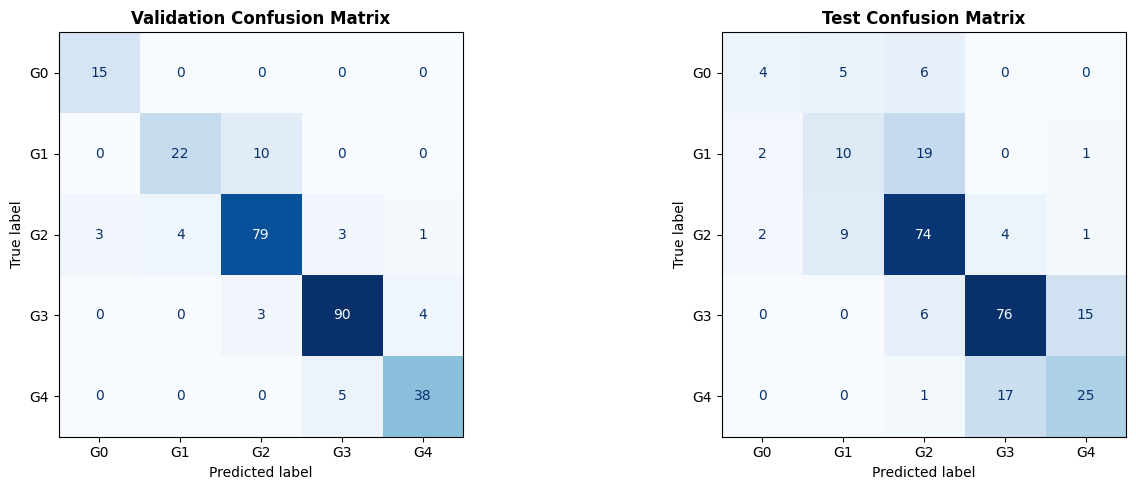

In [24]:
def evaluate_cnn(model, loader, split_name='Val'):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    acc = accuracy_score(all_labels, all_preds)
    print(f'\n{split_name} Accuracy: {acc:.4f}')
    print(classification_report(all_labels, all_preds, target_names=[f'Grade {i}' for i in range(5)]))
    return all_preds, all_labels, np.array(all_probs)

val_preds, val_labels, val_probs   = evaluate_cnn(cnn_model, val_loader,  'Validation')
test_preds, test_labels, test_probs = evaluate_cnn(cnn_model, test_loader, 'TEST (held-out)')

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (preds, labels, title) in zip(axes, [
    (val_preds, val_labels, 'Validation Confusion Matrix'),
    (test_preds, test_labels, 'Test Confusion Matrix'),
]):
    cm   = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=[f'G{i}' for i in range(5)])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'cnn_confusion_matrices.png', dpi=150)
plt.show()


## Module 4 — UKPDS HbA1c Lookup

In [25]:
def grade_to_hba1c_midpoint(grade):
    info = DR_TO_HBA1C[int(grade)]
    lo, hi = info['range']
    return (lo + hi) / 2.0

print('UKPDS lookup table:')
for g, info in DR_TO_HBA1C.items():
    lo, hi = info['range']
    print(f'  Grade {g} ({info["label"]:<20}) → HbA1c {lo}–{hi}%  midpoint: {(lo+hi)/2}%')


UKPDS lookup table:
  Grade 0 (No DR               ) → HbA1c 5.5–6.5%  midpoint: 6.0%
  Grade 1 (Mild DR             ) → HbA1c 6.5–7.5%  midpoint: 7.0%
  Grade 2 (Moderate DR         ) → HbA1c 7.5–8.5%  midpoint: 8.0%
  Grade 3 (Severe DR           ) → HbA1c 8.5–10.0%  midpoint: 9.25%
  Grade 4 (Proliferative DR    ) → HbA1c 10.0–12.0%  midpoint: 11.0%


## Module 5 — Glucose Prediction

NHANES shape: (3670, 3)
       ID  HbA1c  Glucose
0  130378    5.6      113
1  130379    5.6       99
2  130380    6.2      156
3  130386    5.1      100
4  130394    4.8       88
Clean samples: 3665


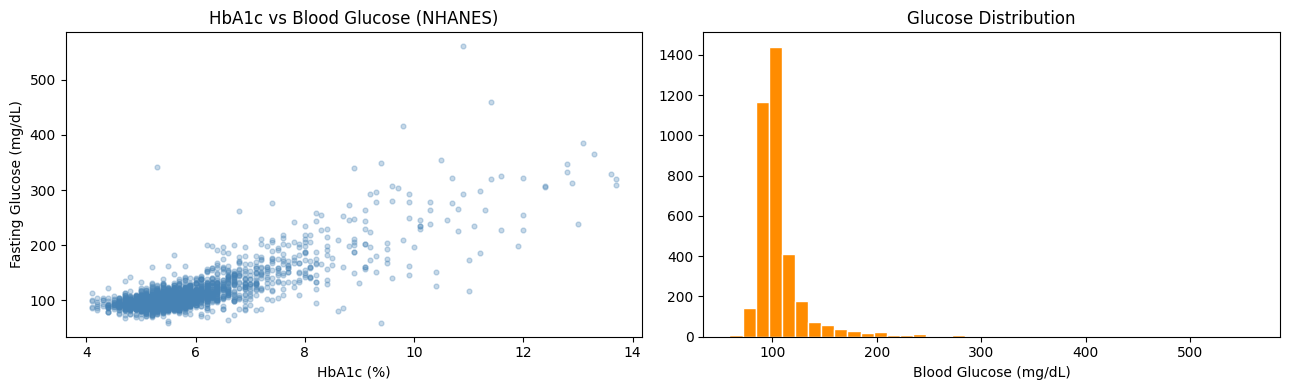

In [26]:
nhanes_df = pd.read_excel(GLUCOSE_XLSX)
print(f'NHANES shape: {nhanes_df.shape}')
print(nhanes_df.head(5))

ml_df = nhanes_df[['HbA1c','Glucose']].dropna()
ml_df = ml_df[(ml_df['HbA1c']  >= 4.0) & (ml_df['HbA1c']  <= 20.0)]
ml_df = ml_df[(ml_df['Glucose'] >= 50)  & (ml_df['Glucose'] <= 600)]
ml_df = ml_df.reset_index(drop=True)
print(f'Clean samples: {len(ml_df)}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(ml_df['HbA1c'], ml_df['Glucose'], alpha=0.3, s=12, color='steelblue')
axes[0].set_xlabel('HbA1c (%)'); axes[0].set_ylabel('Fasting Glucose (mg/dL)')
axes[0].set_title('HbA1c vs Blood Glucose (NHANES)')
axes[1].hist(ml_df['Glucose'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Blood Glucose (mg/dL)'); axes[1].set_title('Glucose Distribution')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'nhanes_eda.png', dpi=150); plt.show()


### Feature Engineering (Key Fix #3 — uses real CNN-predicted DR grade)

In [28]:
def build_features(hba1c_series, dr_grade_series=None):
    """
    Build 7-feature matrix.
    KEY FIX: When dr_grade_series is provided (at inference time),
    the REAL CNN-predicted grade is used — not reconstructed from HbA1c.
    During training on NHANES, we reconstruct grade from HbA1c since NHANES
    doesn't have DR grades — but we also add a note that at inference time
    the real grade flows in.
    """
    h = np.array(hba1c_series, dtype=np.float32)
    if dr_grade_series is None:
        # Reconstruct approximate grade from HbA1c for NHANES training data
        grade = np.zeros_like(h)
        grade[(h >= 6.5) & (h < 7.5)]  = 1
        grade[(h >= 7.5) & (h < 8.5)]  = 2
        grade[(h >= 8.5) & (h < 10.0)] = 3
        grade[h >= 10.0]                = 4
    else:
        grade = np.array(dr_grade_series, dtype=np.float32)

    lo_map = {0:5.5, 1:6.5, 2:7.5, 3:8.5, 4:10.0}
    hi_map = {0:6.5, 1:7.5, 2:8.5, 3:10.0, 4:12.0}
    mid    = np.array([(lo_map[int(g)] + hi_map[int(g)]) / 2 for g in grade])
    rng    = np.array([hi_map[int(g)] - lo_map[int(g)] for g in grade])

    X = np.column_stack([h, h**2, mid, rng, grade**2, grade * h, grade])
    return X

FEATURE_NAMES = ['hba1c','hba1c_sq','hba1c_mid','hba1c_range_w','grade_sq','grade_hba1c','dr_grade']

X_all = build_features(ml_df['HbA1c'])
y_all = ml_df['Glucose'].values

# 3-way split for glucose models too
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_all, y_all, test_size=0.30, random_state=42)
X_val_g, X_te_g, y_val_g, y_te_g = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)

scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_val_sc  = scaler.transform(X_val_g)
X_te_sc   = scaler.transform(X_te_g)

print(f'Glucose — Train: {len(X_tr)} | Val: {len(X_val_g)} | Test: {len(X_te_g)}')
print('Features:', FEATURE_NAMES)


Glucose — Train: 2565 | Val: 550 | Test: 550
Features: ['hba1c', 'hba1c_sq', 'hba1c_mid', 'hba1c_range_w', 'grade_sq', 'grade_hba1c', 'dr_grade']


In [29]:
# ================================
# Convert features to DataFrame + Preview + Save to Excel
# ================================

import pandas as pd

# Convert feature matrix to DataFrame
X_df = pd.DataFrame(X_all, columns=FEATURE_NAMES)

# (Optional) Add target column
X_df['Glucose'] = y_all

# 🔍 Show first few rows
print("Sample Feature Table:")
print(X_df.head())

print("\nShape of table:", X_df.shape)

# 💾 Save to Excel
file_path = "/kaggle/working/glucose_features.xlsx"
X_df.to_excel(file_path, index=False)

print(f"\n✅ File saved successfully at: {file_path}")

Sample Feature Table:
   hba1c   hba1c_sq  hba1c_mid  hba1c_range_w  grade_sq  grade_hba1c  \
0    5.6  31.359999        6.0            1.0       0.0          0.0   
1    5.6  31.359999        6.0            1.0       0.0          0.0   
2    6.2  38.439999        6.0            1.0       0.0          0.0   
3    5.1  26.009998        6.0            1.0       0.0          0.0   
4    4.8  23.040001        6.0            1.0       0.0          0.0   

   dr_grade  Glucose  
0       0.0      113  
1       0.0       99  
2       0.0      156  
3       0.0      100  
4       0.0       88  

Shape of table: (3665, 8)

✅ File saved successfully at: /kaggle/working/glucose_features.xlsx


In [30]:
print('=' * 65)
print('  MODULE 5 — GLUCOSE PREDICTION: 4 MODELS COMPARED')
print('=' * 65)

results = {}

# 1. ADA Formula (baseline)
print('\n[1/4] ADA formula...')
ada_preds = 28.7 * X_te_g[:, 0] - 46.7
results['ADA Formula'] = {
    'mae':  mean_absolute_error(y_te_g, ada_preds),
    'rmse': np.sqrt(mean_squared_error(y_te_g, ada_preds)),
    'r2':   r2_score(y_te_g, ada_preds),
    'preds': ada_preds
}
print(f"  MAE: {results['ADA Formula']['mae']:.2f} | RMSE: {results['ADA Formula']['rmse']:.2f} | R²: {results['ADA Formula']['r2']:.4f}")

# 2. Lasso (LassoCV)
print('\n[2/4] Lasso regression...')
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_tr_sc, y_tr)
lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso.fit(X_tr_sc, y_tr)
lasso_preds = lasso.predict(X_te_sc)
results['Lasso'] = {
    'mae':  mean_absolute_error(y_te_g, lasso_preds),
    'rmse': np.sqrt(mean_squared_error(y_te_g, lasso_preds)),
    'r2':   r2_score(y_te_g, lasso_preds),
    'preds': lasso_preds
}
print(f"  Alpha: {lasso_cv.alpha_:.5f} | MAE: {results['Lasso']['mae']:.2f} | RMSE: {results['Lasso']['rmse']:.2f} | R²: {results['Lasso']['r2']:.4f}")

# 3. CART (GridSearchCV)
print('\n[3/4] CART Decision Tree...')
param_grid = {'max_depth':[4,5,6,7,8], 'min_samples_leaf':[5,10,15,20], 'min_samples_split':[10,20,30]}
cart_gs    = GridSearchCV(DecisionTreeRegressor(criterion='squared_error', random_state=42),
                           param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
cart_gs.fit(X_tr, y_tr)
best_cart  = cart_gs.best_estimator_
cart_preds = best_cart.predict(X_te_g)
results['CART'] = {
    'mae':  mean_absolute_error(y_te_g, cart_preds),
    'rmse': np.sqrt(mean_squared_error(y_te_g, cart_preds)),
    'r2':   r2_score(y_te_g, cart_preds),
    'preds': cart_preds
}
print(f"  Best params: {cart_gs.best_params_}")
print(f"  MAE: {results['CART']['mae']:.2f} | RMSE: {results['CART']['rmse']:.2f} | R²: {results['CART']['r2']:.4f}")

# 4. Random Forest (NEW)
print('\n[4/4] Random Forest...')
rf = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5,
                            random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_preds = rf.predict(X_te_g)
results['Random Forest'] = {
    'mae':  mean_absolute_error(y_te_g, rf_preds),
    'rmse': np.sqrt(mean_squared_error(y_te_g, rf_preds)),
    'r2':   r2_score(y_te_g, rf_preds),
    'preds': rf_preds
}
print(f"  MAE: {results['Random Forest']['mae']:.2f} | RMSE: {results['Random Forest']['rmse']:.2f} | R²: {results['Random Forest']['r2']:.4f}")

# Summary table
results_df = pd.DataFrame([
    {'Model': name, 'MAE': round(v['mae'],2), 'RMSE': round(v['rmse'],2), 'R2': round(v['r2'],4)}
    for name, v in results.items()
]).sort_values('MAE')
print('\n── Final Comparison ──')
print(results_df.to_string(index=False))

best_name = results_df.iloc[0]['Model']
print(f'\n✅ Best model (lowest MAE): {best_name}')


  MODULE 5 — GLUCOSE PREDICTION: 4 MODELS COMPARED

[1/4] ADA formula...
  MAE: 14.84 | RMSE: 22.75 | R²: 0.5392

[2/4] Lasso regression...
  Alpha: 0.27387 | MAE: 10.48 | RMSE: 20.44 | R²: 0.6283

[3/4] CART Decision Tree...
  Best params: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20}
  MAE: 11.02 | RMSE: 21.86 | R²: 0.5746

[4/4] Random Forest...
  MAE: 10.75 | RMSE: 21.10 | R²: 0.6037

── Final Comparison ──
        Model   MAE  RMSE     R2
        Lasso 10.48 20.44 0.6283
Random Forest 10.75 21.10 0.6037
         CART 11.02 21.86 0.5746
  ADA Formula 14.84 22.75 0.5392

✅ Best model (lowest MAE): Lasso


In [31]:
joblib.dump(lasso,    MODEL_DIR/'lasso_glucose.pkl')
joblib.dump(best_cart, MODEL_DIR/'cart_glucose.pkl')
joblib.dump(rf,        MODEL_DIR/'rf_glucose.pkl')
joblib.dump(scaler,    MODEL_DIR/'lasso_scaler.pkl')
joblib.dump(FEATURE_NAMES, MODEL_DIR/'feature_names.pkl')

model_key_map = {'ADA Formula':'ada', 'Lasso':'lasso', 'CART':'cart', 'Random Forest':'rf'}
best_model_key = model_key_map[best_name]
joblib.dump({'name': best_name, 'key': best_model_key}, MODEL_DIR/'best_model_meta.pkl')
results_df.to_csv(OUTPUT_DIR/'model_comparison.csv', index=False)
print('All models saved ✅')


All models saved ✅


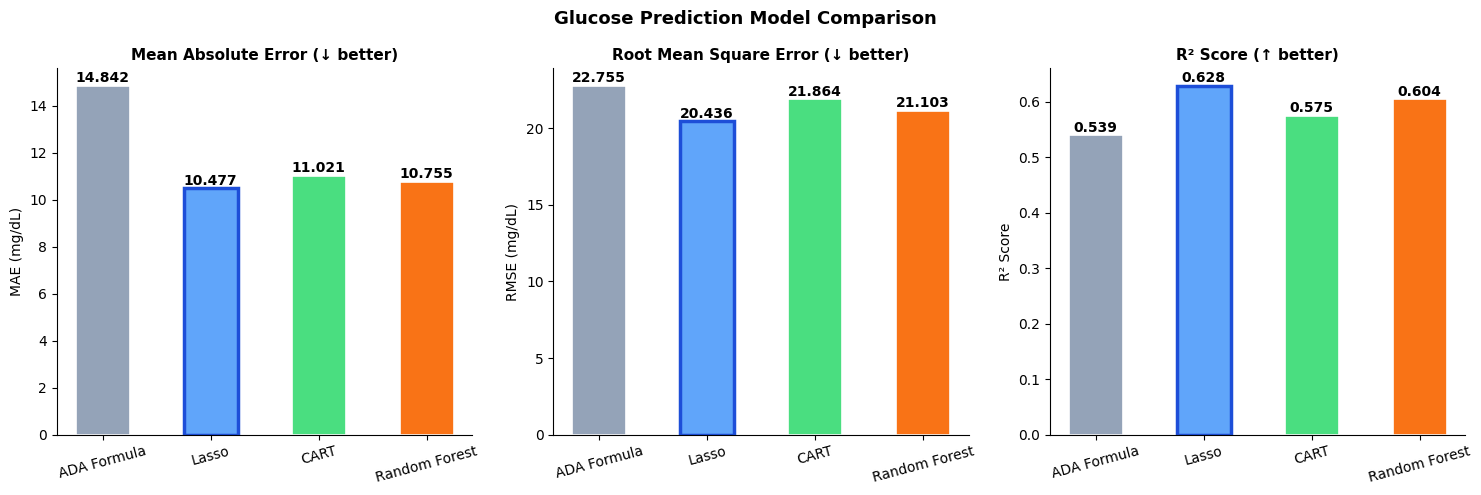

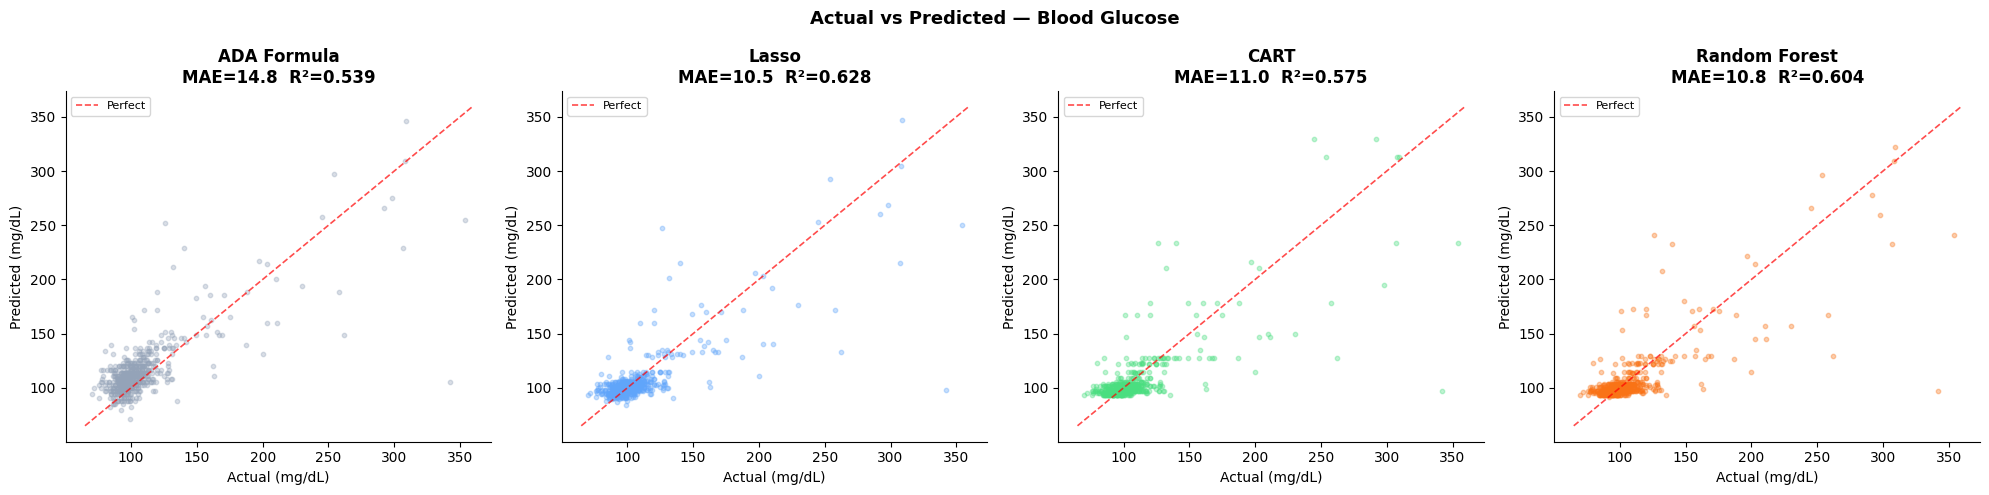

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_names = list(results.keys())
bar_colors  = ['#94a3b8', '#60a5fa', '#4ade80', '#f97316']
metrics_cfg = [
    ([results[n]['mae']  for n in model_names], 'MAE (mg/dL)',  'Mean Absolute Error (↓ better)'),
    ([results[n]['rmse'] for n in model_names], 'RMSE (mg/dL)', 'Root Mean Square Error (↓ better)'),
    ([results[n]['r2']   for n in model_names], 'R² Score',     'R² Score (↑ better)'),
]
for ax, (vals, ylabel, title) in zip(axes, metrics_cfg):
    bars = ax.bar(model_names, vals, color=bar_colors, edgecolor='white', linewidth=1.2, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002*max(abs(x) for x in vals),
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold'); ax.set_ylabel(ylabel)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', rotation=15)
    best_idx = vals.index(min(vals)) if ylabel != 'R² Score' else vals.index(max(vals))
    bars[best_idx].set_edgecolor('#1d4ed8'); bars[best_idx].set_linewidth(2.5)
plt.suptitle('Glucose Prediction Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'model_comparison_bars.png', dpi=150); plt.show()

# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, color) in zip(axes, zip(model_names, bar_colors)):
    preds = results[name]['preds']
    ax.scatter(y_te_g, preds, alpha=0.35, s=10, color=color)
    lim = [min(y_te_g.min(), preds.min())-5, max(y_te_g.max(), preds.max())+5]
    ax.plot(lim, lim, 'r--', lw=1.2, alpha=0.7, label='Perfect')
    ax.set_title(f'{name}\nMAE={results[name]["mae"]:.1f}  R²={results[name]["r2"]:.3f}', fontweight='bold')
    ax.set_xlabel('Actual (mg/dL)'); ax.set_ylabel('Predicted (mg/dL)')
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
plt.suptitle('Actual vs Predicted — Blood Glucose', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'actual_vs_predicted.png', dpi=150); plt.show()


In [33]:
print(os.listdir('/kaggle/input/datasets/shrvx08/retina-image'))

['1334_3.png']


## End-to-End Inference Function

In [35]:
def predict_glucose_from_retina(image_input, verbose=True):
    """
    Full pipeline: fundus image → DR grade → HbA1c → blood glucose.
    KEY FIX: real CNN-predicted grade now flows into glucose feature engineering.
    Includes confidence thresholding.
    """
    seg_model.eval(); cnn_model.eval()

    # Load image
    if isinstance(image_input, (str, Path)):
        img_bgr = cv2.imread(str(image_input))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = image_input

    img_pre = preprocess_fundus(img_rgb, target_size=IMG_SIZE)

    # Step 1: U-Net segmentation
    seg_tf = A.Compose([A.Resize(IMG_SIZE,IMG_SIZE),
                        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2()])
    seg_in = seg_tf(image=img_pre, mask=np.zeros((IMG_SIZE,IMG_SIZE), dtype=np.uint8))['image']
    with torch.no_grad():
        mask = seg_model(seg_in.unsqueeze(0).to(DEVICE)).argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    # Step 2: CNN classification
    img_224  = cv2.resize(img_pre, (224, 224))
    mask_224 = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)
    rgb_t    = T.Compose([T.ToPILImage(), T.ToTensor(),
                          T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])(img_224)
    mask_t   = torch.tensor(mask_224 / 6.0).unsqueeze(0).float()
    cnn_in   = torch.cat([rgb_t, mask_t], dim=0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        proba = torch.softmax(cnn_model(cnn_in), dim=1).squeeze(0).cpu().numpy()

    grade      = int(np.argmax(proba))
    confidence = proba[grade]
    uncertain  = confidence < CONF_THRESH

    # Step 3: UKPDS lookup
    info      = DR_TO_HBA1C[grade]
    lo, hi    = info['range']
    mid_hba1c = (lo + hi) / 2.0

    # Step 4: Glucose prediction — REAL grade fed into features
    feat = build_features([mid_hba1c], dr_grade_series=[grade])
    if best_model_key == 'ada':
        glucose = float(28.7 * mid_hba1c - 46.7)
    elif best_model_key == 'lasso':
        glucose = float(lasso.predict(scaler.transform(feat))[0])
    elif best_model_key == 'cart':
        glucose = float(best_cart.predict(feat)[0])
    else:
        glucose = float(rf.predict(feat)[0])

    lesion_counts    = {LESION_NAMES[i]: int((mask == i).sum()) for i in range(1, 7)}
    detected_lesions = [k for k, v in lesion_counts.items() if v > 50]

    result = {
        'img_pre': img_pre, 'mask': mask,
        'grade': grade, 'label': info['label'], 'risk': info['risk'],
        'color': info['color'], 'confidence': confidence*100,
        'uncertain': uncertain, 'proba': proba,
        'hba1c_lo': lo, 'hba1c_hi': hi, 'hba1c_mid': mid_hba1c,
        'glucose_mgdl': round(glucose, 1),
        'lesion_counts': lesion_counts, 'detected_lesions': detected_lesions,
        'best_model': best_name,
    }

    if verbose:
        flag = ' ⚠️  LOW CONFIDENCE — treat as uncertain' if uncertain else ''
        print(f'DR Grade   : {grade} — {info["label"]}{flag}')
        print(f'Confidence : {confidence*100:.1f}%')
        print(f'HbA1c range: {lo}% – {hi}%  (midpoint {mid_hba1c}%)')
        print(f'Glucose    : {round(glucose,1)} mg/dL  (via {best_name})')
        print(f'Risk       : {info["risk"]}')
        print(f'Lesions    : {", ".join(detected_lesions) if detected_lesions else "None detected"}')

    return result

print('Inference function ready ✅')


Inference function ready ✅


In [36]:
def visualise_result(result, save_path=None):
    img_pre = result['img_pre']; mask = result['mask']
    grade   = result['grade'];   color = result['color']

    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls_id, c in LESION_COLORS.items():
        color_mask[mask == cls_id] = c
    overlay = cv2.addWeighted(img_pre, 0.6, color_mask, 0.4, 0)

    fig = plt.figure(figsize=(18, 7))
    gs  = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.3)

    ax0 = fig.add_subplot(gs[0, 0]); ax0.imshow(img_pre)
    ax0.set_title('Preprocessed Image', fontweight='bold'); ax0.axis('off')

    ax1 = fig.add_subplot(gs[0, 1]); ax1.imshow(overlay)
    ax1.set_title('Lesion Overlay', fontweight='bold'); ax1.axis('off')
    patches = [mpatches.Patch(color=np.array(c)/255, label=LESION_NAMES[i])
               for i, c in LESION_COLORS.items() if i > 0]
    ax1.legend(handles=patches, loc='lower right', fontsize=6)

    ax2 = fig.add_subplot(gs[0, 2])
    grade_labels = [f'G{i}' for i in range(5)]
    bar_cols     = ['#22C55E','#EAB308','#F97316','#EF4444','#991B1B']
    bars2 = ax2.bar(grade_labels, result['proba']*100, color=bar_cols, edgecolor='white')
    bars2[grade].set_edgecolor('black'); bars2[grade].set_linewidth(2.5)
    ax2.set_ylabel('Confidence (%)'); ax2.set_title('Grade Probabilities', fontweight='bold')
    ax2.set_ylim(0, 110)
    for b, v in zip(bars2, result['proba']*100):
        if v > 2:
            ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{v:.1f}', ha='center', fontsize=8)
    ax2.axhline(CONF_THRESH*100, color='red', ls='--', lw=1, label=f'Threshold ({CONF_THRESH*100:.0f}%)')
    ax2.legend(fontsize=7); ax2.spines[['top','right']].set_visible(False)

    ax3 = fig.add_subplot(gs[0, 3]); ax3.axis('off')
    uncertain_flag = '\n⚠️  LOW CONFIDENCE' if result['uncertain'] else ''
    summary = (
        f"DR Grade   : {grade}\n"
        f"Diagnosis  : {result['label']}\n"
        f"Confidence : {result['confidence']:.1f}%{uncertain_flag}\n\n"
        f"HbA1c range: {result['hba1c_lo']}–{result['hba1c_hi']}%\n"
        f"HbA1c mid  : {result['hba1c_mid']}%\n\n"
        f"Glucose    : {result['glucose_mgdl']} mg/dL\n"
        f"Risk       : {result['risk']}\n\n"
        f"Model used : {result['best_model']}"
    )
    ax3.text(0.05, 0.95, summary, transform=ax3.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))
    ax3.set_title('Prediction Summary', fontweight='bold')

    ax4 = fig.add_subplot(gs[1, :])
    lesion_vals   = [result['lesion_counts'][LESION_NAMES[i]] for i in range(1, 7)]
    lesion_cols   = ['#ef4444','#22c55e','#3b82f6','#f59e0b','#a855f7','#06b6d4']
    bars4 = ax4.bar(list(LESION_NAMES.values()), lesion_vals, color=lesion_cols, edgecolor='white')
    for b, v in zip(bars4, lesion_vals):
        ax4.text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v), ha='center', fontsize=9)
    ax4.set_ylabel('Pixels detected'); ax4.set_title('Lesion Pixel Counts', fontweight='bold')
    ax4.spines[['top','right']].set_visible(False)

    plt.suptitle(f'RetinaScan AI — Grade {grade} ({result["label"]}) | Glucose: {result["glucose_mgdl"]} mg/dL',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    sp = save_path or OUTPUT_DIR/'full_prediction_report.png'
    plt.savefig(str(sp), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {sp}')

print('Visualisation function ready ✅')


Visualisation function ready ✅


DR Grade   : 4 — Proliferative DR
Confidence : 91.5%
HbA1c range: 10.0% – 12.0%  (midpoint 11.0%)
Glucose    : 263.5 mg/dL  (via Lasso)
Risk       : Very High
Lesions    : Microaneurysms, Hemorrhages


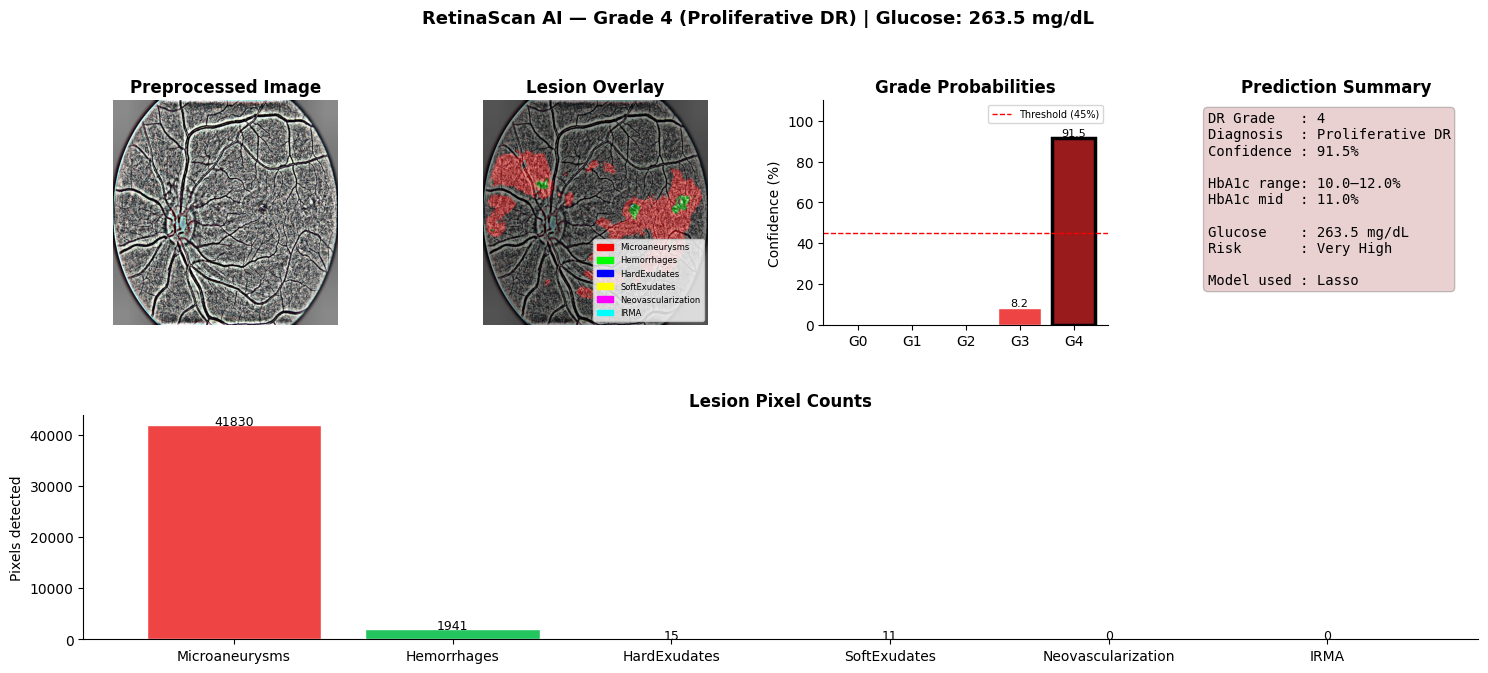

Saved: /kaggle/working/outputs/full_prediction_report.png

 RetinaScan AI Final Output
DR Grade   : 4 — Proliferative DR
Confidence : 91.5%
HbA1c      : 10.0% – 12.0%
Glucose    : 263.5 mg/dL
Risk       : Very High
Lesions    : Microaneurysms, Hemorrhages


In [37]:
# ================================
# 🚀 FULL PIPELINE RUN + VISUALIZATION
# ================================

# 1. Give your image path
img_path = "/kaggle/input/datasets/shrvx08/retina-image/1334_3.png"  # 🔁 change this

# 2. Run prediction
result = predict_glucose_from_retina(img_path)

# 3. Visualize result
visualise_result(result)

# ================================
# (Optional) Print clean summary again
# ================================
print("\n==============================")
print(" RetinaScan AI Final Output")
print("==============================")
print(f"DR Grade   : {result['grade']} — {result['label']}")
print(f"Confidence : {result['confidence']:.1f}%")
print(f"HbA1c      : {result['hba1c_lo']}% – {result['hba1c_hi']}%")
print(f"Glucose    : {result['glucose_mgdl']} mg/dL")
print(f"Risk       : {result['risk']}")
print(f"Lesions    : {', '.join(result['detected_lesions']) if result['detected_lesions'] else 'None'}")
print("==============================")

DR Grade   : 4 — Proliferative DR
Confidence : 78.3%
HbA1c range: 10.0% – 12.0%  (midpoint 11.0%)
Glucose    : 263.5 mg/dL  (via Lasso)
Risk       : Very High
Lesions    : Microaneurysms, Hemorrhages, HardExudates


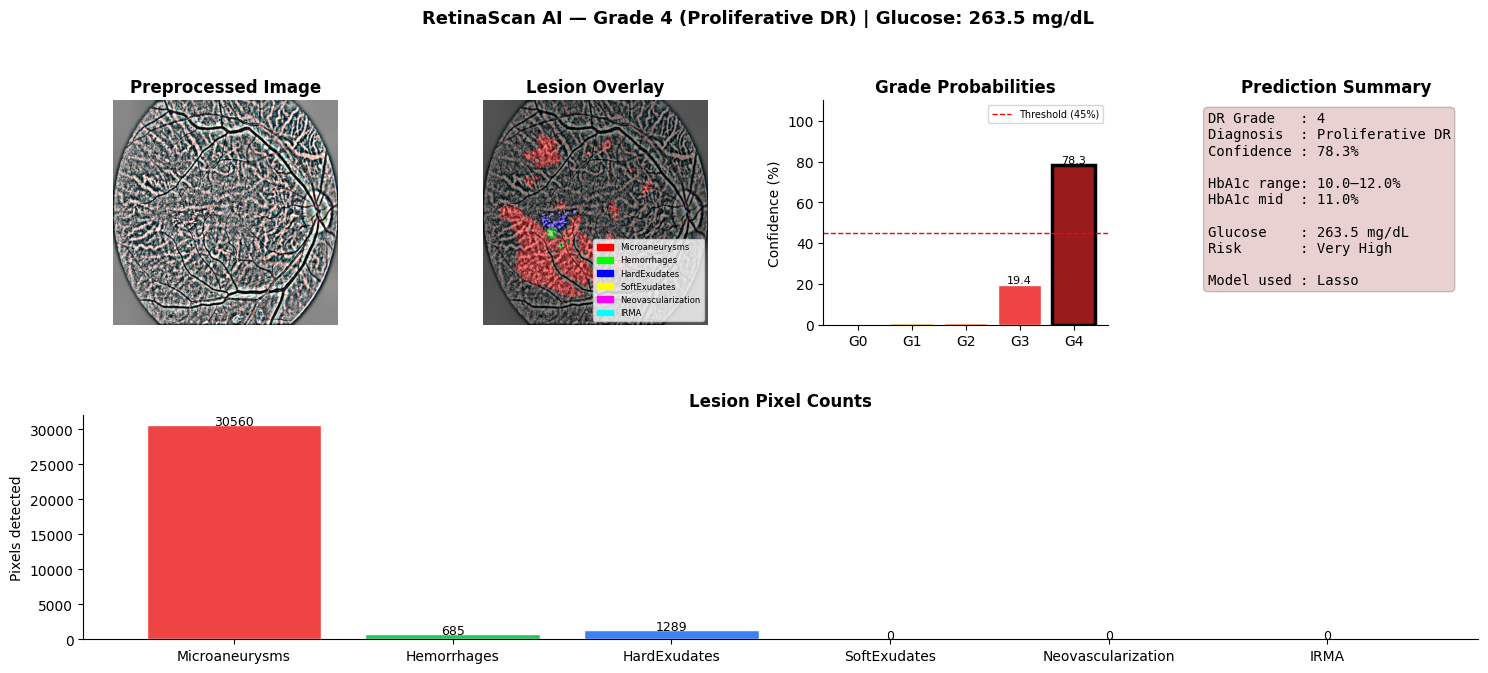

Saved: /kaggle/working/outputs/full_prediction_report.png


In [38]:
# Run end-to-end inference on a sample validation image
sample_imgs = list(IMAGE_DIR.glob('*.jpg'))[:3] + list(IMAGE_DIR.glob('*.png'))[:3]
if sample_imgs:
    result = predict_glucose_from_retina(sample_imgs[0])
    visualise_result(result)
else:
    print('No sample images found — check IMAGE_DIR path')


## Final Model File Check

In [39]:
print('Checking all saved model files...')
model_files = [
    'unet_efficientb4_fgadr.pth',
    'cnn_drgrade_resnet50.pth',
    'lasso_glucose.pkl', 'lasso_scaler.pkl',
    'cart_glucose.pkl',  'rf_glucose.pkl',
    'feature_names.pkl', 'best_model_meta.pkl',
]
for mf in model_files:
    path = MODEL_DIR / mf
    size = f'{path.stat().st_size/1e6:.1f} MB' if path.exists() else 'MISSING'
    print(f'  {"✅" if path.exists() else "❌"} {mf:<40} {size}')

print('\nFinal Glucose Model Comparison:')
print(results_df.to_string(index=False))
print(f'\nBest model selected: {best_name}')
print(f'\nAll outputs at: {OUTPUT_DIR}')
print('\n🎉 RetinaScan AI — Kaggle run complete!')


Checking all saved model files...
  ✅ unet_efficientb4_fgadr.pth               81.7 MB
  ✅ cnn_drgrade_resnet50.pth                 99.1 MB
  ✅ lasso_glucose.pkl                        0.0 MB
  ✅ lasso_scaler.pkl                         0.0 MB
  ✅ cart_glucose.pkl                         0.0 MB
  ✅ rf_glucose.pkl                           1.9 MB
  ✅ feature_names.pkl                        0.0 MB
  ✅ best_model_meta.pkl                      0.0 MB

Final Glucose Model Comparison:
        Model   MAE  RMSE     R2
        Lasso 10.48 20.44 0.6283
Random Forest 10.75 21.10 0.6037
         CART 11.02 21.86 0.5746
  ADA Formula 14.84 22.75 0.5392

Best model selected: Lasso

All outputs at: /kaggle/working/outputs

🎉 RetinaScan AI — Kaggle run complete!


In [41]:
import shutil, os

SAVE_DIR = Path('/kaggle/working/models_to_save')
SAVE_DIR.mkdir(exist_ok=True)

files_to_persist = [
    'unet_efficientb4_fgadr.pth',
    'unet_efficientb4_checkpoint.pth',
    'cnn_drgrade_resnet50.pth',
    'cnn_drgrade_checkpoint.pth',
    'lasso_glucose.pkl',
    'cart_glucose.pkl',
    'rf_glucose.pkl',
    'lasso_scaler.pkl',
    'feature_names.pkl',
    'best_model_meta.pkl',
]

print('Copying updated models to output...')
for fname in files_to_persist:
    src = MODEL_DIR / fname
    dst = SAVE_DIR / fname
    if src.exists():
        shutil.copy(str(src), str(dst))
        size = src.stat().st_size / 1e6
        print(f'  ✅ {fname:<45} {size:.1f} MB')
    else:
        print(f'  ❌ Missing: {fname}')

print(f'\nAll files saved to {SAVE_DIR}')
print('Go to Output tab → Download → re-upload as new version of retinascan-models dataset')

Copying updated models to output...
  ✅ unet_efficientb4_fgadr.pth                    81.7 MB
  ✅ unet_efficientb4_checkpoint.pth               237.5 MB
  ✅ cnn_drgrade_resnet50.pth                      99.1 MB
  ✅ cnn_drgrade_checkpoint.pth                    296.8 MB
  ✅ lasso_glucose.pkl                             0.0 MB
  ✅ cart_glucose.pkl                              0.0 MB
  ✅ rf_glucose.pkl                                1.9 MB
  ✅ lasso_scaler.pkl                              0.0 MB
  ✅ feature_names.pkl                             0.0 MB
  ✅ best_model_meta.pkl                           0.0 MB

All files saved to /kaggle/working/models_to_save
Go to Output tab → Download → re-upload as new version of retinascan-models dataset


In [42]:
import shutil
shutil.make_archive('/kaggle/working/models_backup', 'zip', SAVE_DIR)
print("✅ ZIP created")

✅ ZIP created
